## Load Data

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("D:/OneDrive/+Study/C Projects/fintech-credit-risk-model/Data/processed/cleaned_loans.csv")

df.shape

(1371166, 23)

## Define Features and Target

In [6]:
X = df.drop(columns=["target_default"])

y = df["target_default"]

split into train and test sets based on Time to simulate forward-looking underwriting deployment and reduce temporal leadkage.

In [8]:
df["issue_d"] = pd.to_datetime(df["issue_d"])

train_df = df[df["issue_d"] < "2016-01-01"]
test_df  = df[df["issue_d"] >= "2016-01-01"]

C:\Users\59171\AppData\Local\Temp\ipykernel_15380\113809880.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["issue_d"] = pd.to_datetime(df["issue_d"])


In [19]:
X_train = train_df.drop(columns=["target_default", "issue_d"])
y_train = train_df["target_default"]

X_test = test_df.drop(columns=["target_default", "issue_d"])
y_test = test_df["target_default"]

## Preprocessing

In [21]:
# Identify Coloumn types
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns

numeric_cols = X_train.select_dtypes(
    exclude=["object"]
).columns

C:\Users\59171\AppData\Local\Temp\ipykernel_15380\1942710764.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [23]:
# building preprocessing pipelines for both numeric and categorical data
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [24]:
# Numeric preprocessing pipeline
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [25]:
# categorical preprocessing pipeline
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)


In [26]:
# combine numeric and categorical pipelines into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

## Logistic Regression Baseline

In [30]:
# Build model pipeline
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [28]:
# Train the model
log_reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [29]:
# Predict probabilities
log_pred_prob = log_reg_pipeline.predict_proba(X_test)[:,1]

## LightGBM

In [31]:
from lightgbm import LGBMClassifier

lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        ))
    ]
)

In [32]:
# Train the model
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 154352, number of negative: 674302
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3130
[LightGBM] [Info] Number of data points in the train set: 828654, number of used features: 720
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.186268 -> initscore=-1.474442
[LightGBM] [Info] Start training from score -1.474442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [33]:
# Predict probabilities
lgbm_pred_prob = lgbm_pipeline.predict_proba(X_test)[:,1]

c:\Users\59171\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## Evaluate Models

In [34]:
# ROC-AUC
from sklearn.metrics import roc_auc_score

log_auc = roc_auc_score(y_test, log_pred_prob)
lgbm_auc = roc_auc_score(y_test, lgbm_pred_prob)

print(log_auc)
print(lgbm_auc)

0.6943226554371476
0.702557933410235


AUC measures ranking quality which allows the model to assign higher risk scores to riskier borrowers.

***Precision / recall***

convert probabilities to classes

In [35]:
threshold = 0.5

In [36]:
from sklearn.metrics import classification_report

log_pred_class = (
    log_pred_prob >= threshold
).astype(int)

print(
    classification_report(
        y_test,
        log_pred_class
    )
)

              precision    recall  f1-score   support

           0       0.74      1.00      0.85    402449
           1       0.61      0.02      0.03    140063

    accuracy                           0.74    542512
   macro avg       0.68      0.51      0.44    542512
weighted avg       0.71      0.74      0.64    542512



## ROC Curve

In [37]:
from sklearn.metrics import roc_curve

log_fpr, log_tpr, _ = roc_curve(
    y_test,
    log_pred_prob
)

lgbm_fpr, lgbm_tpr, _ = roc_curve(
    y_test,
    lgbm_pred_prob
)

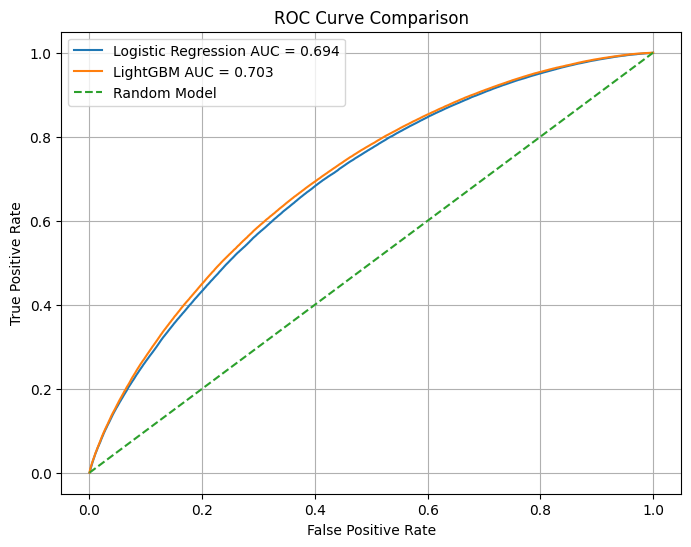

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve values
log_fpr, log_tpr, _ = roc_curve(y_test, log_pred_prob)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_pred_prob)

# Calculate AUC scores
log_auc = roc_auc_score(y_test, log_pred_prob)
lgbm_auc = roc_auc_score(y_test, lgbm_pred_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression AUC = {log_auc:.3f}"
)

plt.plot(
    lgbm_fpr,
    lgbm_tpr,
    label=f"LightGBM AUC = {lgbm_auc:.3f}"
)

# Random model baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

***Save results***

In [39]:
# save prediction results
results_df = X_test.copy()

results_df["actual_default"] = y_test.values

results_df["log_pred_prob"] = log_pred_prob

results_df["lgbm_pred_prob"] = lgbm_pred_prob

In [40]:
results_df.to_csv(
    "../data/processed/model_predictions.csv",
    index=False
)

In [45]:
# save trained model pipelines
import joblib

joblib.dump(
    log_reg_pipeline,
    "../Models/log_reg_pipeline.pkl"
)
joblib.dump(
    lgbm_pipeline,
    "../models/lgbm_pipeline.pkl"
)

['../models/lgbm_pipeline.pkl']

## Initial interpretation

The LightGBM model demonstrated stronger discriminatory
power than logistic regression, suggesting nonlinear
relationships between borrower characteristics and default
risk.

However, logistic regression retained advantages in
interpretability and coefficient transparency, which remain
important considerations in regulated credit-risk settings.